In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import joblib
import streamlit as st

In [3]:
# 1. Load the dataset (Make sure 'CAR DETAILS FROM CAR DEKHO.csv' is in the same folder as this script)
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')

print("--- Initial Data Shape ---")
print(df.shape) 
print(df.head())


--- Initial Data Shape ---
(4340, 8)
                       name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  


In [4]:
# 2. Data Preprocessing
# We'll drop the 'name' column for simplicity to avoid high cardinality, 
# or you could extract the brand. Let's drop it for a simple baseline model.
# Convert categorical variables into dummy/indicator variables (One-Hot Encoding)
df_processed = pd.get_dummies(df.drop(columns=['name']), drop_first=True)

In [5]:
# 3. Define Features (X) and Target (y)
X = df_processed.drop(columns=['selling_price'])
y = df_processed['selling_price']

In [6]:
# 4. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# 5. Train the Model
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 35880.2 , -1. ,299081.42,...,-36546.35,130421.44,-26864.48]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['year','km_driven','fuel_Diesel',...,'owner_Second Owner', 'owner_Test Drive Car','owner_Third Owner']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-7.095e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


In [8]:
# 6. Predict and Evaluate
predictions = model.predict(X_test)

print("\n--- Model Evaluation Results ---")
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, predictions))
print("Root Mean Squared Error (RMSE):", root_mean_squared_error(y_test, predictions))


--- Model Evaluation Results ---
Mean Absolute Error (MAE): 221585.88022516813
Root Mean Squared Error (RMSE): 426721.2831097459


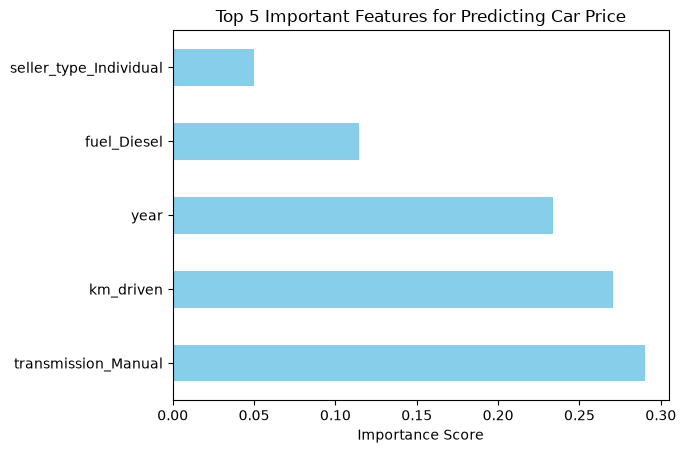

In [9]:
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')
df_processed = pd.get_dummies(df.drop(columns=['name']), drop_first=True)
X = df_processed.drop(columns=['selling_price'])
y = df_processed['selling_price']

# Train a Random Forest Model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X, y)

# Plot Feature Importances
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh', color='skyblue')
plt.title('Top 5 Important Features for Predicting Car Price')
plt.xlabel('Importance Score')
plt.show()

In [10]:
# Train a Random Forest model instead of Linear Regression
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
rf_predictions = rf_model.predict(X_test)
print("Random Forest MAE:", mean_absolute_error(y_test, rf_predictions))
print("Random Forest RMSE:", root_mean_squared_error(y_test, rf_predictions))

Random Forest MAE: 168994.44108928187
Random Forest RMSE: 392030.0028125828


In [11]:
# Create a sample dictionary for a new car to predict its price
new_car = pd.DataFrame([{
    'year': 2018,
    'km_driven': 35000,
    'fuel_Diesel': 0,
    'fuel_Electric': 0,
    'fuel_LPG': 0,
    'fuel_Petrol': 1,
    'seller_type_Individual': 1,
    'transmission_Manual': 1,
    'owner_Fourth & Above Owner': 0,
    'owner_Second Owner': 0,
    'owner_Test Drive Car': 0,
    'owner_Third Owner': 0
}])

# Ensure columns match your training features order
new_car = new_car.reindex(columns=X.columns, fill_value=0)

# Predict price
predicted_price = rf_model.predict(new_car)
print(f"Estimated Selling Price: ₹{predicted_price[0]:,.2f}")

Estimated Selling Price: ₹401,096.11


In [12]:
# Define parameters to test
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Run Grid Search
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           scoring='neg_mean_squared_error',
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# Evaluate the tuned model
tuned_preds = best_model.predict(X_test)
print("Tuned Model MAE:", mean_absolute_error(y_test, tuned_preds))
print("Tuned Model RMSE:", root_mean_squared_error(y_test, tuned_preds))

Best Parameters Found: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Tuned Model MAE: 169719.6594451884
Tuned Model RMSE: 394927.55772103235


In [13]:
# Save the best model to disk
joblib.dump(best_model, 'car_price_model.pkl')
print("Model saved successfully as 'car_price_model.pkl'")

# How to load it later for predictions:
# loaded_model = joblib.load('car_price_model.pkl')
# prediction = loaded_model.predict(new_car)

Model saved successfully as 'car_price_model.pkl'


In [14]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# Load the trained model
@st.cache_resource
def load_model():
    return joblib.load('car_price_model.pkl')

model = load_model()

st.title("🚗 Car Price Prediction App")
st.write("Enter your car's details below to estimate its market resale price.")

# User Inputs
year = st.number_input("Manufacturing Year", min_value=1990, max_value=2026, value=2018)
km_driven = st.number_input("Kilometers Driven", min_value=0, max_value=500000, value=35000)
fuel = st.selectbox("Fuel Type", ["Petrol", "Diesel", "CNG", "LPG", "Electric"])
seller_type = st.selectbox("Seller Type", ["Individual", "Dealer", "Trustmark Dealer"])
transmission = st.selectbox("Transmission", ["Manual", "Automatic"])
owner = st.selectbox("Owner Type", ["First Owner", "Second Owner", "Third Owner", "Fourth & Above Owner", "Test Drive Car"])

if st.button("Predict Price"):
    # Create input dataframe mapping to training dummy columns
    input_data = pd.DataFrame([{
        'year': year,
        'km_driven': km_driven,
        'fuel_Diesel': 1 if fuel == 'Diesel' else 0,
        'fuel_Electric': 1 if fuel == 'Electric' else 0,
        'fuel_LPG': 1 if fuel == 'LPG' else 0,
        'fuel_Petrol': 1 if fuel == 'Petrol' else 0,
        'seller_type_Individual': 1 if seller_type == 'Individual' else 0,
        'seller_type_Trustmark Dealer': 1 if seller_type == 'Trustmark Dealer' else 0,
        'transmission_Manual': 1 if transmission == 'Manual' else 0,
        'owner_Fourth & Above Owner': 1 if owner == 'Fourth & Above Owner' else 0,
        'owner_Second Owner': 1 if owner == 'Second Owner' else 0,
        'owner_Test Drive Car': 1 if owner == 'Test Drive Car' else 0,
        'owner_Third Owner': 1 if owner == 'Third Owner' else 0
    }])
    
    # Align columns to match training features exactly
    # (If your columns differ slightly from the get_dummies structure, adjust here)
    prediction = model.predict(input_data)[0]
    
    st.success(f"Estimated Resale Price: ₹ {prediction:,.2f}")
    

2026-09-11 12:26:20.851 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 12:26:21.296 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 12:26:23.050 
  command:

    streamlit run C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-11 12:26:23.051 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 12:26:23.052 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 12:26:23.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 12:26:23.056 Thread 'MainThread': missing ScriptRunContext! This warning can 